In [1]:
!pip install -q -U transformers
!pip install -q -U datasets
!pip install -q -U accelerate
!pip install -q -U evaluate
!pip install -q -U scikit-learn
!pip install -q -U wandb
!pip install -q sentencepiece

## **Import Libraries**

In [2]:
import os
import random
import numpy as np
import pandas as pd
import torch

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding
)

from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

import wandb

In [3]:
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: nguyenthu-m462004 (nguyenthu-m462004-fpt-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Config**

In [5]:
# DATA

DATASET_PATH = "/content/drive/MyDrive/5.SemanticMapping/scope_dataset/scope_dataset_balanced.csv"

TEXT_COLUMN = "text"
LABEL_COLUMN = "scope"

# MODEL

MODEL_NAME = "climatebert/distilroberta-base-climate-f"

OUTPUT_DIR = "/content/drive/MyDrive/5.SemanticMapping/ClimateBERT_Scope"

# TRAINING

MAX_LENGTH = 256

BATCH_SIZE = 16

LR = 1e-5

WEIGHT_DECAY = 0.01

NUM_EPOCHS = 20

SEEDS = [42, 123, 2026, 3407, 8888]

## **Seed**

In [6]:
def set_seed(seed):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed(seed)

        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False

## **Load dataset**

In [7]:
df = pd.read_csv(DATASET_PATH)

print(df.shape)

df.head()

(4838, 14)


,block_id,page,text,type,confidence,semantic_standard,semantic_document,semantic_score,matched_chunk,matched_page,matched_document,scope,bbox,quality_score
0,6196,hoa_phat_group_jsc_2025_p037_jpg.rf.52ccc19901...,"However, the large-scale adoption of these sol...",text,0.996382,ghg-protocol-revised,ghg-protocol-revised,0.984993,", use and disposal of refrigeration and air- c...",46,ghg-protocol-revised,Scope 1,NaN,3.369986
1,11859,vietnam_airlines_jsc_2024_p010_jpg.rf.37067598...,"As the flag air carrier of Vietnam, VNA is re...",text,0.996859,ghg-protocol-revised,ghg-protocol-revised,0.984196,. G U I D A N C E Business Goals and Inventory...,16,ghg-protocol-revised,Scope 1,NaN,3.368391
2,8005,masan_group_corp_2024_p080_jpg.rf.85cd3d38b052...,(i) These balances represented interest income...,text,0.982753,ghg-protocol-revised,ghg-protocol-revised,0.983702,. (Chapter 10) Mobile combustion Burning of fu...,102,ghg-protocol-revised,Scope 1,NaN,3.367404
3,13145,vietnam_national_petroleum_group_2024_p068_jpg...,Petrolimex has been always paying attention to...,text,0.996503,GRI 14,GRI 14_ Mining Sector 2024 V1.1,0.982823,". Note 2: The ILO Minimum Age Convention, 1973...",73,GRI 14_ Mining Sector 2024 V1.1,Scope 1,NaN,3.365646
4,11238,vicostone_jsc_2024_p149_jpg.rf.99580ae7c72d002...,Vicostone completed assessing 100% key supplie...,text,0.996553,GRI 13,GRI 13_ Agriculture Aquaculture and Fishing Se...,0.981044,. Describe actions taken to support the econom...,61,GRI 13_ Agriculture Aquaculture and Fishing Se...,Scope 1,NaN,3.362088


In [8]:
assert df["scope"].isnull().sum() == 0

In [9]:
df["scope"].value_counts()

,count
scope,
Other,1700
Scope 3,1138
Scope 2,1000
Scope 1,1000


In [10]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [11]:
# Keep text + label only
df = df[
    [
        "text",
        "scope"
    ]
].copy()

In [12]:
# Delete empty text
df = df.dropna(subset=["text"])

df["text"] = df["text"].astype(str)

df = df[df["text"].str.strip() != ""]

## **Label Mapping**

In [13]:
label2id = {

    "Other":0,

    "Scope 1":1,

    "Scope 2":2,

    "Scope 3":3

}

id2label = {v:k for k,v in label2id.items()}

In [14]:
# Encode label
df["label"] = df["scope"].map(label2id)

In [15]:
df.head()

,text,scope,label
0,"In each building, depending on the conditions ...",Other,0
1,4.Risks\nThe 2021 - 2025 period represents a t...,Scope 3,3
2,Boost individual and organizational performance.,Other,0
3,Year 2014: 21.97 million kWh/year (an increase...,Scope 2,2
4,Product structure shifts: Focus on uniquely de...,Scope 2,2


In [16]:
print(df["label"].value_counts())

label
0    1700
3    1138
2    1000
1    1000
Name: count, dtype: int64


In [17]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

True
Tesla T4


## **Train / Validation / Test**

In [18]:
SPLIT_SEED = 42

train_df, temp_df = train_test_split(

    df,

    test_size=0.2,

    stratify=df["label"],

    random_state=SPLIT_SEED

)

valid_df, test_df = train_test_split(

    temp_df,

    test_size=0.5,

    stratify=temp_df["label"],

    random_state=SPLIT_SEED

)

## **Convert to HuggingFace Dataset**

In [19]:
train_dataset = Dataset.from_pandas(train_df)

valid_dataset = Dataset.from_pandas(valid_df)

test_dataset = Dataset.from_pandas(test_df)

In [20]:
if "__index_level_0__" in train_dataset.column_names:
    train_dataset = train_dataset.remove_columns(["__index_level_0__"])

if "__index_level_0__" in valid_dataset.column_names:
    valid_dataset = valid_dataset.remove_columns(["__index_level_0__"])

if "__index_level_0__" in test_dataset.column_names:
    test_dataset = test_dataset.remove_columns(["__index_level_0__"])

In [21]:
# Check
print(train_dataset)

print(valid_dataset)

print(test_dataset)

Dataset({
    features: ['text', 'scope', 'label'],
    num_rows: 3870
})
Dataset({
    features: ['text', 'scope', 'label'],
    num_rows: 484
})
Dataset({
    features: ['text', 'scope', 'label'],
    num_rows: 484
})


In [22]:
print(train_dataset.features)

{'text': Value('string'), 'scope': Value('string'), 'label': Value('int64')}


## **Tokenizer**

In [23]:
print("=" * 60)
print("Loading ClimateBERT...")
print("=" * 60)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(tokenizer.model_max_length)
print(tokenizer.vocab_size)

Loading ClimateBERT...


512
50265


## **Tokenize Dataset**

In [24]:
def tokenize_function(examples):

    return tokenizer(

        examples["text"],

        truncation=True,

        max_length=MAX_LENGTH,

        padding=False,

        return_attention_mask=True
    )


train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

valid_dataset = valid_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

Map:   0%|          | 0/3870 [00:00<?, ? examples/s]

Map:   0%|          | 0/484 [00:00<?, ? examples/s]

Map:   0%|          | 0/484 [00:00<?, ? examples/s]

In [25]:
# check token length
lengths = []

for x in train_dataset:

    lengths.append(len(x["input_ids"]))

print("Average:", np.mean(lengths))
print("Maximum:", np.max(lengths))

Average: 86.2687338501292
Maximum: 256


(array([212., 381., 354., 286., 199., 171., 152., 126., 144.,  99.,  95.,
         91.,  86., 100.,  74.,  70.,  89.,  49.,  45.,  85.,  80.,  29.,
         33.,  59.,  34.,  34.,  49.,  36.,  43.,  35.,  21.,  32.,  23.,
         25.,  22.,  23.,   7.,  36.,  22., 319.]),
 array([  4. ,  10.3,  16.6,  22.9,  29.2,  35.5,  41.8,  48.1,  54.4,
         60.7,  67. ,  73.3,  79.6,  85.9,  92.2,  98.5, 104.8, 111.1,
        117.4, 123.7, 130. , 136.3, 142.6, 148.9, 155.2, 161.5, 167.8,
        174.1, 180.4, 186.7, 193. , 199.3, 205.6, 211.9, 218.2, 224.5,
        230.8, 237.1, 243.4, 249.7, 256. ]),
 <BarContainer object of 40 artists>)

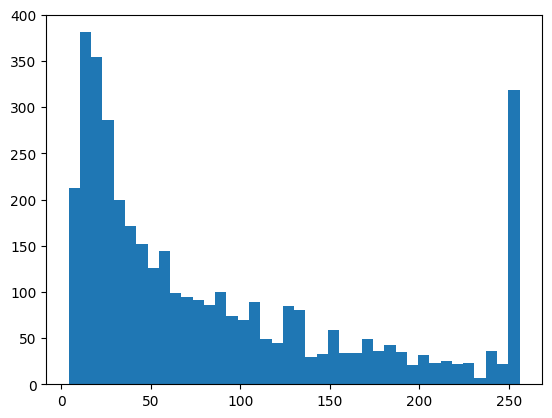

In [26]:
import matplotlib.pyplot as plt
plt.hist(lengths,bins=40)

## **Compute Metrics**

In [27]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,

        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,

        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1
    }

Check Transformers Version

In [28]:
import transformers
import inspect

print(transformers.__version__)

print(inspect.signature(TrainingArguments))

5.14.1
(output_dir: str | None = None, per_device_train_batch_size: int = 8, num_train_epochs: float = 3.0, max_steps: int = -1, learning_rate: float = 5e-05, lr_scheduler_type: transformers.trainer_utils.SchedulerType | str = 'linear', lr_scheduler_kwargs: dict | str | None = None, warmup_steps: float = 0, optim: transformers.training_args.OptimizerNames | str = 'adamw_torch_fused', optim_args: str | None = None, weight_decay: float = 0.0, adam_beta1: float = 0.9, adam_beta2: float = 0.999, adam_epsilon: float = 1e-08, optim_target_modules: None | str | list[str] = None, gradient_accumulation_steps: int = 1, average_tokens_across_devices: bool = True, max_grad_norm: float = 1.0, label_smoothing_factor: float = 0.0, bf16: bool = False, fp16: bool = False, bf16_full_eval: bool = False, fp16_full_eval: bool = False, tf32: bool | None = None, gradient_checkpointing: bool = False, gradient_checkpointing_kwargs: dict[str, typing.Any] | str | None = None, torch_compile: bool = False, torch_c

# **Fine-tune ClimateBERT**

In [29]:
from transformers.trainer_utils import get_last_checkpoint

In [30]:
all_results = []

best_f1 = -1
best_seed = None
best_trainer = None
best_checkpoint = None

for seed in SEEDS:

    print("=" * 60)
    print(f"Training with seed = {seed}")
    print("=" * 60)

    set_seed(seed)

    # ======================================================
    # Load ClimateBERT
    # ======================================================

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(label2id),
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True,
    )

    # ======================================================
    # Training Arguments
    # ======================================================

    training_args = TrainingArguments(

        output_dir=os.path.join(
            OUTPUT_DIR,
            f"seed_{seed}"
        ),

        do_train=True,
        do_eval=True,

        eval_strategy="steps",
        eval_steps=200,
        save_strategy="steps",
        save_steps=200,

        logging_strategy="epoch",
        logging_steps=50,

        learning_rate=LR,

        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,

        num_train_epochs=NUM_EPOCHS,

        weight_decay=WEIGHT_DECAY,

        warmup_ratio = 0.1,

        optim="adamw_torch",

        load_best_model_at_end=True,

        metric_for_best_model="macro_f1",

        greater_is_better=True,

        save_total_limit=1,

        report_to="wandb",

        run_name=f"seed_{seed}",

        fp16=torch.cuda.is_available(),

        seed=seed,
    )

    # ======================================================
    # Trainer
    # ======================================================

    trainer = Trainer(

        model=model,

        args=training_args,

        train_dataset=train_dataset,

        eval_dataset=valid_dataset,

        processing_class=tokenizer,

        data_collator=data_collator,

        compute_metrics=compute_metrics,

        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=2
            )
        ]
    )

    checkpoint_dir = os.path.join(
        OUTPUT_DIR,
        f"seed_{seed}"
    )

    completed_flag = os.path.join(
        checkpoint_dir,
        "completed.txt"
    )

    if os.path.exists(completed_flag):
        print(f"Seed {seed} already finished. Skip.")
        continue

    # ======================================================
    # WandB
    # ======================================================

    wandb.init(

        project="climatebert-scope",

        name=f"seed_{seed}",

        config={

            "seed": seed,

            "model_name": MODEL_NAME,

            "batch_size": BATCH_SIZE,

            "learning_rate": LR,

            "max_length": MAX_LENGTH,

            "weight_decay": WEIGHT_DECAY,

            "epochs": NUM_EPOCHS,

            "train_size": len(train_dataset),

            "valid_size": len(valid_dataset),

            "test_size": len(test_dataset),

            "class_distribution": train_df["scope"].value_counts().to_dict()
        }
    )

    class_counts = train_df["scope"].value_counts().reset_index()
    class_counts.columns = ["Class", "Count"]

    table = wandb.Table(dataframe=class_counts)

    wandb.log({

        "Class Distribution": table,

        "Class Distribution Bar":

            wandb.plot.bar(
                table,
                "Class",
                "Count",
                title="Training Class Distribution"
            )

    })

    last_checkpoint = None

    if os.path.isdir(checkpoint_dir):
        last_checkpoint = get_last_checkpoint(checkpoint_dir)

    if last_checkpoint is not None:

        print("=" * 60)
        print(f"Resume from: {last_checkpoint}")
        print("=" * 60)

        trainer.train(
            resume_from_checkpoint=last_checkpoint
        )

    else:

        trainer.train()

    # ======================================================
    # Train
    # ======================================================

    trainer.save_state()
    os.makedirs(checkpoint_dir, exist_ok=True)

    with open(completed_flag, "w") as f:
        f.write("done")
    train_metrics = trainer.evaluate(
        eval_dataset=train_dataset,
        metric_key_prefix="train"
    )

    # ======================================================
    # Validation
    # ======================================================

    val_metrics = trainer.evaluate(
        eval_dataset=valid_dataset,
        metric_key_prefix="eval"
    )

    # ======================================================
    # Test
    # ======================================================
    test_metrics = trainer.evaluate(
        eval_dataset=test_dataset,
        metric_key_prefix="test"
    )

    # ======================================================
    # Save Results
    # ======================================================

    result = {
        "seed": seed,
        **train_metrics,
        **val_metrics,
        **test_metrics
    }

    all_results.append(result)

    wandb.log(result)

    # ======================================================
    # Save Best Model
    # ======================================================

    if val_metrics["eval_macro_f1"] > best_f1:

        best_f1 = val_metrics["eval_macro_f1"]

        best_seed = seed

        best_trainer = trainer

        best_checkpoint = trainer.state.best_model_checkpoint

    wandb.finish()

# ==========================================================
# Save Best Model
# ==========================================================
if best_trainer is None:
    raise RuntimeError("No model was trained successfully.")

BEST_MODEL_DIR = os.path.join(
    OUTPUT_DIR,
    "best_scope_classifier"
)

best_trainer.save_model(BEST_MODEL_DIR)

tokenizer.save_pretrained(BEST_MODEL_DIR)

print("=" * 60)
print("Training Finished")
print("=" * 60)

wandb.init(
    project="climatebert-scope",
    name="best-summary"
)

wandb.summary["best_seed"] = best_seed
wandb.summary["best_validation_f1"] = best_f1
wandb.summary["best_checkpoint"] = best_checkpoint

wandb.finish()

print(f"Best Seed            : {best_seed}")
print(f"Best Validation F1   : {best_f1:.4f}")
print(f"Best Checkpoint      : {best_checkpoint}")
print(f"Best model saved to  : {BEST_MODEL_DIR}")

Training with seed = 42


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: climatebert/distilroberta-base-climate-f
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
200,No log,1.349040,0.351240,0.087810,0.250000,0.129969,0.123369,0.351240,0.182602
400,1.366898,0.667306,0.768595,0.768579,0.768527,0.767894,0.769635,0.768595,0.768565
600,0.871629,0.478385,0.838843,0.843678,0.849445,0.843856,0.846383,0.838843,0.839609
800,0.414133,0.363381,0.869835,0.873109,0.875315,0.872876,0.874033,0.869835,0.870558
1000,0.251822,0.272191,0.940083,0.947456,0.937975,0.942158,0.941099,0.940083,0.939971
1200,0.251822,0.308066,0.925620,0.924350,0.933658,0.928514,0.925903,0.925620,0.925235
1400,0.154408,0.285456,0.942149,0.945362,0.942949,0.943979,0.942181,0.942149,0.941988
1600,0.112452,0.305123,0.933884,0.934515,0.940570,0.937280,0.934015,0.933884,0.933672
1800,0.081321,0.293079,0.938017,0.937790,0.943403,0.939989,0.938252,0.938017,0.937587


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

eval/accuracy,▁▆▇▇▇██████
eval/loss,█▃▂▂▂▁▁▁▁▁▁
eval/macro_f1,▁▆▇▇▇██████
eval/macro_precision,▁▇▇▇▇██████
eval/macro_recall,▁▆▇▇▇██████
eval/runtime,▁▃█▁▄▁▃▂▅▂▁
eval/samples_per_second,█▅▁█▄█▅▇▄▇█
eval/steps_per_second,█▅▁█▄█▅▇▄▇█
eval/weighted_f1,▁▆▇▇▇██████
eval/weighted_precision,▁▇▇▇███████
+49,...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Finished


best_checkpoint,/content/drive/MyDri...
best_seed,3407
best_validation_f1,0.9537


Best Seed            : 3407
Best Validation F1   : 0.9537
Best Checkpoint      : /content/drive/MyDrive/5.SemanticMapping/ClimateBERT_Scope/seed_3407/checkpoint-1600
Best model saved to  : /content/drive/MyDrive/5.SemanticMapping/ClimateBERT_Scope/best_scope_classifier


training_config.json

In [31]:
import json
training_config = {

    "model_name": MODEL_NAME,
    "best_seed": best_seed,
    "best_validation_f1": float(best_f1),
    "best_checkpoint": best_checkpoint,

    "epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "weight_decay": WEIGHT_DECAY,
    "max_length": MAX_LENGTH,
    "optimizer": "AdamW",

    "train_size": len(train_df),
    "valid_size": len(valid_df),
    "test_size": len(test_df)

}

with open(

    os.path.join(

        BEST_MODEL_DIR,

        "training_config.json"

    ),

    "w"

) as f:

    json.dump(
        training_config,
        f,
        indent=4
    )

label_mapping.json

In [32]:
with open(

    os.path.join(

        BEST_MODEL_DIR,

        "label_mapping.json"

    ),

    "w"

) as f:

    json.dump(

        {

            "label2id": label2id,

            "id2label": id2label

        },

        f,

        indent=4

    )

training_summary.csv

In [33]:
summary_df = pd.DataFrame(all_results)

comparison = summary_df[
    [
        "seed",
        "eval_accuracy",
        "eval_macro_f1",
        "eval_weighted_f1",
        "test_accuracy",
        "test_macro_f1"
    ]
]

wandb.init(
    project="climatebert-scope",
    name="training-summary",
    job_type="summary"
)

wandb.log({

    "Macro F1 by Seed":

        wandb.plot.bar(

            wandb.Table(dataframe=comparison),

            "seed",

            "eval_macro_f1",

            title="Validation Macro F1"

        )

})

summary_df.to_csv(

    os.path.join(

        BEST_MODEL_DIR,

        "training_summary.csv"

    ),

    index=False

)

wandb.finish()

results_summary.csv

In [34]:
results_summary = pd.DataFrame({

    "Metric":[

        "accuracy",
        "precision",
        "recall",
        "macro_f1",
        "weighted_f1"

    ],

    "Mean":[

        summary_df["eval_accuracy"].mean(),
        summary_df["eval_macro_precision"].mean(),
        summary_df["eval_macro_recall"].mean(),
        summary_df["eval_macro_f1"].mean(),
        summary_df["eval_weighted_f1"].mean()

    ],

    "Std":[

        summary_df["eval_accuracy"].std(),
        summary_df["eval_macro_precision"].std(),
        summary_df["eval_macro_recall"].std(),
        summary_df["eval_macro_f1"].std(),
        summary_df["eval_weighted_f1"].std()

    ]

})

results_summary.to_csv(

    os.path.join(

        BEST_MODEL_DIR,

        "results_summary.csv"

    ),

    index=False

)

classification_report.txt

In [35]:
wandb.init(
    project="climatebert-scope",
    name="classification-report",
    job_type="analysis"
)
predictions = best_trainer.predict(test_dataset)
y_pred = predictions.predictions.argmax(axis=1)
y_true = predictions.label_ids

In [36]:
report = classification_report(

    y_true,

    y_pred,

    target_names=[

        id2label[i]

        for i in range(len(id2label))

    ]

)

with open(

    os.path.join(

        BEST_MODEL_DIR,

        "classification_report.txt"

    ),

    "w",

    encoding="utf-8"

) as f:

    f.write(report)

classification_report.json

In [37]:
import json

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=[
        id2label[i]
        for i in range(len(id2label))
    ],
    output_dict=True,
    zero_division=0
)

report_df = (
    pd.DataFrame(report_dict)
      .transpose()
      .reset_index()
      .rename(columns={"index":"Class"})
)

wandb.log({
    "Classification Report Table":
        wandb.Table(dataframe=report_df)
})

with open(
    os.path.join(
        BEST_MODEL_DIR,
        "classification_report.json"
    ),
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        report_dict,
        f,
        indent=4,
        ensure_ascii=False
    )

print("Saved classification_report.json")

Saved classification_report.json


confusion_matrix.png

In [38]:
cm = confusion_matrix(y_true, y_pred)

wandb.log({
    "Interactive Confusion Matrix":
        wandb.plot.confusion_matrix(
            y_true=y_true,
            preds=y_pred,
            class_names=list(label2id.keys())
        )
})

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(label2id.keys())
)

fig, ax = plt.subplots(figsize=(7,7))
disp.plot(ax=ax)
plt.tight_layout()

cm_path = os.path.join(
    BEST_MODEL_DIR,
    "confusion_matrix.png"
)

plt.savefig(cm_path)
plt.close()

confusion_matrix.csv

In [39]:
cm_df = pd.DataFrame(
    cm,
    index=[f"True_{x}" for x in label2id.keys()],
    columns=[f"Pred_{x}" for x in label2id.keys()]
)

cm_df.to_csv(
    os.path.join(
        BEST_MODEL_DIR,
        "confusion_matrix.csv"
    ),
    encoding="utf-8-sig"
)

print("Saved confusion_matrix.csv")

Saved confusion_matrix.csv


predictions.csv

In [40]:
import torch
import torch.nn.functional as F

# Convert logits -> probabilities
probs = F.softmax(
    torch.tensor(predictions.predictions),
    dim=1
).numpy()

confidence = probs.max(axis=1)

predictions_df = pd.DataFrame({

    "text": test_df["text"].reset_index(drop=True),

    "true_id": y_true,

    "pred_id": y_pred,

    "true_label": [
        id2label[i]
        for i in y_true
    ],

    "pred_label": [
        id2label[i]
        for i in y_pred
    ],

    "confidence": confidence,

    "correct": (
        y_true == y_pred
    )

})

wandb.log({

    "Correct Predictions":

        wandb.Table(

            dataframe=predictions_df.sort_values(

                "confidence",

                ascending=False

            ).head(100)

        ),

    "Prediction Confidence":
        wandb.Histogram(confidence),

    "Misclassified Samples":
        wandb.Table(dataframe=predictions_df[predictions_df["correct"] == False])
})

predictions_path = os.path.join(
    BEST_MODEL_DIR,
    "predictions.csv"
)

predictions_df.to_csv(
    predictions_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"Saved predictions to: {predictions_path}")
wandb.finish()

Saved predictions to: /content/drive/MyDrive/5.SemanticMapping/ClimateBERT_Scope/best_scope_classifier/predictions.csv


test/accuracy,▁
test/loss,▁
test/macro_f1,▁
test/macro_precision,▁
test/macro_recall,▁
test/runtime,▁
test/samples_per_second,▁
test/steps_per_second,▁
test/weighted_f1,▁
test/weighted_precision,▁
+1,...


README.txt

In [41]:
from datetime import datetime
import platform
import transformers
import torch

In [42]:
readme = f"""
============================================================
ClimateBERT Scope Classifier
============================================================

Dataset
-------
{DATASET_PATH}

Model
-----
{MODEL_NAME}

Tokenizer
---------
{MODEL_NAME}

Number of Classes
-----------------
{len(label2id)}

Labels
------
0 : Other
1 : Scope 1
2 : Scope 2
3 : Scope 3

Training Information
--------------------
Training Date : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

Best Seed : {best_seed}

Best Validation F1 : {best_f1:.4f}

Best Checkpoint : {best_checkpoint}

Hyperparameters
---------------
Epochs        : {NUM_EPOCHS}
Batch Size    : {BATCH_SIZE}
Learning Rate : {LR}
Weight Decay  : {WEIGHT_DECAY}
Max Length    : {MAX_LENGTH}

Environment
-----------
Python          : {platform.python_version()}
PyTorch         : {torch.__version__}
Transformers    : {transformers.__version__}
CUDA Available  : {torch.cuda.is_available()}
CUDA Version    : {torch.version.cuda}
Device          : {"GPU" if torch.cuda.is_available() else "CPU"}

Saved Files
-----------
config.json
model.safetensors
tokenizer.json
tokenizer_config.json
special_tokens_map.json

training_config.json
label_mapping.json

training_summary.csv
results_summary.csv
predictions.csv

classification_report.txt
classification_report.json

confusion_matrix.png
confusion_matrix.csv

README.txt

============================================================
This folder contains the best ClimateBERT Scope Classifier
obtained during multi-seed fine-tuning.
============================================================
"""

with open(
    os.path.join(
        BEST_MODEL_DIR,
        "README.txt"
    ),
    "w",
    encoding="utf-8"
) as f:
    f.write(readme)

## **Upload Artifacts on WandB**

In [43]:
import os
import json
import pandas as pd
import wandb

# ======================================================
# Start Artifact Run
# ======================================================

wandb.init(

    project="climatebert-scope",

    name="best-model-artifacts",

    job_type="artifacts",

    config={

        "best_seed": best_seed,

        "best_validation_f1": best_f1,

        "model": MODEL_NAME,

        "epochs": NUM_EPOCHS,

        "batch_size": BATCH_SIZE,

        "learning_rate": LR,

        "weight_decay": WEIGHT_DECAY,

        "max_length": MAX_LENGTH
    }
)

# ======================================================
# Upload Best Model
# ======================================================

model_artifact = wandb.Artifact(

    name="best_scope_classifier",

    type="model",

    description="Best ClimateBERT Scope Classifier"

)

model_artifact.metadata.update({
    "model": MODEL_NAME,
    "seed": best_seed,
    "macro_f1": best_f1,
    "epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "weight_decay": WEIGHT_DECAY
})

model_artifact.add_dir(BEST_MODEL_DIR)

wandb.log_artifact(model_artifact)

# ======================================================
# Upload Images
# ======================================================

cm_png = os.path.join(
    BEST_MODEL_DIR,
    "confusion_matrix.png"
)

if os.path.exists(cm_png):

    wandb.log({

        "Confusion Matrix": wandb.Image(cm_png)

    })

# ======================================================
# Upload Tables
# ======================================================

table_files = [

    "training_summary.csv",

    "results_summary.csv",

    "predictions.csv",

    "confusion_matrix.csv"

]

for file in table_files:

    path = os.path.join(
        BEST_MODEL_DIR,
        file
    )

    if os.path.exists(path):

        df = pd.read_csv(path)

        wandb.log({

            file.replace(".csv",""): wandb.Table(
                dataframe=df
            )

        })

# ======================================================
# Upload Classification Report
# ======================================================

json_path = os.path.join(
    BEST_MODEL_DIR,
    "classification_report.json"
)

if os.path.exists(json_path):

    with open(
        json_path,
        "r",
        encoding="utf-8"
    ) as f:

        report = json.load(f)

    wandb.log(report)

# ======================================================
# Upload Text Files
# ======================================================

text_files = [

    "README.txt",

    "classification_report.txt",

    "training_config.json",

    "label_mapping.json"

]

for file in text_files:

    path = os.path.join(
        BEST_MODEL_DIR,
        file
    )

    if os.path.exists(path):

        wandb.save(path)

# ======================================================
# Upload Whole Folder
# ======================================================

wandb.save(
    os.path.join(
        BEST_MODEL_DIR,
        "*"
    )
)

wandb.finish()

print("=" * 60)
print("Artifacts uploaded successfully to WandB")
print("=" * 60)

wandb: Adding directory to artifact (/content/drive/MyDrive/5.SemanticMapping/ClimateBERT_Scope/best_scope_classifier)... Done. 1.7s
wandb: WARNING Saving files without folders. If you want to preserve subdirectories pass base_path to wandb.save, i.e. wandb.save("/mnt/folder/file.h5", base_path="/mnt")
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.
wandb: WARNING Symlinked 11 files into the W&B run directory; call wandb.save again to sync new files.


accuracy,▁
accuracy,0.94421


Artifacts uploaded successfully to WandB


best checkpoint

In [44]:
print("=" * 60)
print("Best Model Summary")
print("=" * 60)

print(f"Best Seed          : {best_seed}")
print(f"Best Validation F1 : {best_f1:.4f}")
print(f"Best Checkpoint    : {best_checkpoint}")
print(f"Saved Model        : {BEST_MODEL_DIR}")

print("=" * 60)

Best Model Summary
Best Seed          : 3407
Best Validation F1 : 0.9537
Best Checkpoint    : /content/drive/MyDrive/5.SemanticMapping/ClimateBERT_Scope/seed_3407/checkpoint-1600
Saved Model        : /content/drive/MyDrive/5.SemanticMapping/ClimateBERT_Scope/best_scope_classifier


Evaluate on Test Set

In [45]:
print("=" * 60)
print("Evaluate Best Model on Test Set")
print("=" * 60)

# Initialize a new W&B run for final evaluation
wandb.init(
    project="climatebert-scope",
    name="final-test-evaluation", # A new descriptive name for this run
    job_type="evaluation",
    reinit=True # Reinitialize if a run somehow already exists
)

metrics = best_trainer.evaluate(test_dataset)

for k, v in metrics.items():
    print(f"{k:20s}: {v:.4f}")

# End the W&B run after evaluation
wandb.finish()

Evaluate Best Model on Test Set


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Training Loss,Validation Loss,Step,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0.053145,0.256822,2000,0.944215,0.946081,0.945142,0.945485,0.944104,0.944215,0.944046


eval_loss           : 0.2568
eval_accuracy       : 0.9442
eval_macro_precision: 0.9461
eval_macro_recall   : 0.9451
eval_macro_f1       : 0.9455
eval_weighted_precision: 0.9441
eval_weighted_recall: 0.9442
eval_weighted_f1    : 0.9440


eval/accuracy,▁
eval/loss,▁
eval/macro_f1,▁
eval/macro_precision,▁
eval/macro_recall,▁
eval/runtime,▁
eval/samples_per_second,▁
eval/steps_per_second,▁
eval/weighted_f1,▁
eval/weighted_precision,▁
+3,...


## **Classification Report**

In [46]:
wandb.init(
    project="climatebert-scope",
    name="final-test-predictions", # A new descriptive name for this run
    job_type="prediction",
    reinit=True # Reinitialize if a run somehow already exists
)

predictions = best_trainer.predict(test_dataset)

y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

y_true = predictions.label_ids

print("=" * 60)
print("Classification Report")
print("=" * 60)

print(

    classification_report(

        y_true,

        y_pred,

        target_names=[
            id2label[i]
            for i in range(len(id2label))
        ]

    )

)

wandb.finish()

Classification Report
              precision    recall  f1-score   support

       Other       0.94      0.95      0.94       170
     Scope 1       0.96      0.94      0.95       100
     Scope 2       0.96      0.99      0.98       100
     Scope 3       0.93      0.90      0.92       114

    accuracy                           0.94       484
   macro avg       0.95      0.95      0.95       484
weighted avg       0.94      0.94      0.94       484



test/accuracy,▁
test/loss,▁
test/macro_f1,▁
test/macro_precision,▁
test/macro_recall,▁
test/runtime,▁
test/samples_per_second,▁
test/steps_per_second,▁
test/weighted_f1,▁
test/weighted_precision,▁
+1,...


Confusion Matrix

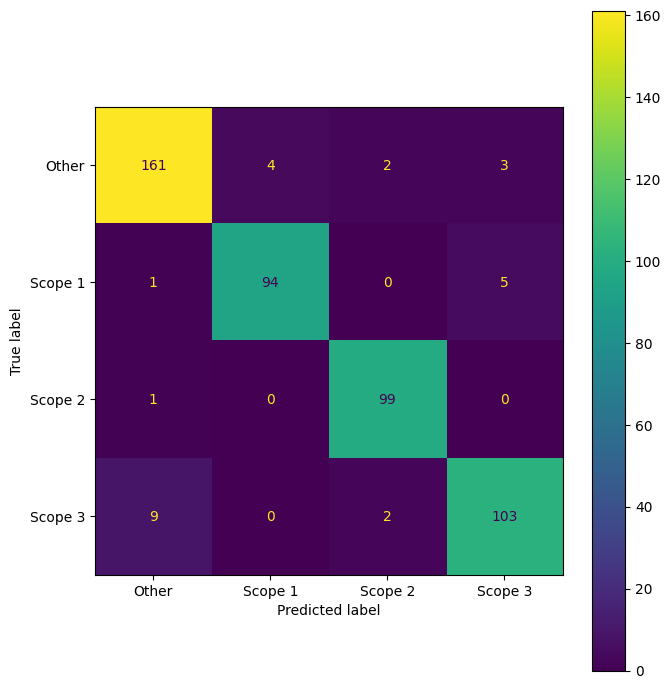

In [47]:
cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=list(label2id.keys())

)

fig, ax = plt.subplots(figsize=(7,7))

disp.plot(ax=ax)

plt.tight_layout()

plt.show()

##**Load Saved Model**

In [48]:
loaded_model = AutoModelForSequenceClassification.from_pretrained(
    BEST_MODEL_DIR
)

loaded_tokenizer = AutoTokenizer.from_pretrained(
    BEST_MODEL_DIR
)

loaded_model.eval()

print("Best model loaded successfully.")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Best model loaded successfully.


## **All seed results**

In [49]:
results_df = pd.DataFrame(all_results)

display(results_df)

print("=" * 60)
print("Mean")
print("=" * 60)

display(
    results_df.mean(numeric_only=True)
)

print("=" * 60)
print("Std")
print("=" * 60)

display(
    results_df.std(numeric_only=True)
)

,seed,train_loss,train_accuracy,train_macro_precision,train_macro_recall,train_macro_f1,train_weighted_precision,train_weighted_recall,train_weighted_f1,eval_loss,...,eval_weighted_recall,eval_weighted_f1,test_loss,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_precision,test_weighted_recall,test_weighted_f1
0,42,0.068617,0.982171,0.982533,0.983333,0.982905,0.982191,0.982171,0.982157,0.285456,...,0.942149,0.941988,0.283338,0.938017,0.943808,0.938364,0.940797,0.938588,0.938017,0.938018
1,123,0.019016,0.995090,0.994498,0.995651,0.995056,0.995130,0.995090,0.995093,0.225780,...,0.944215,0.943836,0.269958,0.948347,0.951161,0.951171,0.950731,0.948729,0.948347,0.948137
2,2026,0.039153,0.989922,0.989411,0.990877,0.990123,0.989953,0.989922,0.989918,0.284851,...,0.944215,0.943957,0.270654,0.948347,0.952518,0.949528,0.950808,0.948638,0.948347,0.948288
3,3407,0.044154,0.987597,0.986815,0.989207,0.987966,0.987660,0.987597,0.987585,0.238866,...,0.950413,0.950172,0.256822,0.944215,0.946081,0.945142,0.945485,0.944104,0.944215,0.944046
4,8888,0.049809,0.988372,0.988659,0.988865,0.988714,0.988437,0.988372,0.988360,0.248863,...,0.946281,0.946016,0.307482,0.940083,0.946901,0.939727,0.942577,0.941279,0.940083,0.939938


Mean


,0
seed,2897.200000
train_loss,0.044150
train_accuracy,0.988630
train_macro_precision,0.988383
train_macro_recall,0.989587
train_macro_f1,0.988953
train_weighted_precision,0.988674
train_weighted_recall,0.988630
train_weighted_f1,0.988623
eval_loss,0.256763


Std


,0
seed,3631.698046
train_loss,0.017940
train_accuracy,0.004644
train_macro_precision,0.004336
train_macro_recall,0.004422
train_macro_f1,0.004365
train_weighted_precision,0.004648
train_weighted_recall,0.004644
train_weighted_f1,0.004650
eval_loss,0.027179


## **Test predict**

In [50]:
sample = """
Purchased electricity consumed during the reporting year
"""

inputs = loaded_tokenizer(

    sample,

    return_tensors="pt",

    truncation=True,

    max_length=MAX_LENGTH

)

with torch.no_grad():

    outputs = loaded_model(**inputs)

pred = outputs.logits.argmax(-1).item()

probs = torch.softmax(
    outputs.logits,
    dim=1
)

confidence = probs.max().item()

print("=" * 60)
print("Prediction")
print("=" * 60)

print("Text:")
print(sample)

print()

print("Predicted Label :", id2label[pred])

print("Confidence      :", round(confidence,4))

Prediction
Text:

Purchased electricity consumed during the reporting year


Predicted Label : Scope 2
Confidence      : 0.9992


# Reuse

In [51]:
# ==========================================================
# Reuse ClimateBERT Scope Classifier
# ==========================================================

import os
import json
import torch
import torch.nn.functional as F

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

MODEL_PATH = "/content/drive/MyDrive/5.SemanticMapping/ClimateBERT_Scope/best_scope_classifier"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ----------------------------------------------------------
# Load tokenizer
# ----------------------------------------------------------

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

# ----------------------------------------------------------
# Load model
# ----------------------------------------------------------

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH
)

model.to(DEVICE)
model.eval()

# ----------------------------------------------------------
# Load label mapping
# ----------------------------------------------------------

with open(
    os.path.join(
        MODEL_PATH,
        "label_mapping.json"
    ),
    "r",
    encoding="utf-8"
) as f:

    mapping = json.load(f)

label2id = mapping["label2id"]

id2label = {
    int(k): v
    for k, v in mapping["id2label"].items()
}

print("Model loaded successfully.")
print(label2id)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Model loaded successfully.
{'Other': 0, 'Scope 1': 1, 'Scope 2': 2, 'Scope 3': 3}


In [52]:
# ==========================================================
# Prediction Function
# ==========================================================

def predict_scope(
    text,
    max_length=256
):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length
    )

    inputs = {
        k: v.to(DEVICE)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        outputs = model(**inputs)

        probs = F.softmax(
            outputs.logits,
            dim=-1
        )[0]

    pred_id = torch.argmax(probs).item()

    prediction = id2label[pred_id]

    confidence = probs[pred_id].item()

    probabilities = {

        id2label[i]: round(
            probs[i].item(),
            4
        )

        for i in range(len(probs))
    }

    return {

        "prediction": prediction,

        "confidence": confidence,

        "probabilities": probabilities

    }

In [53]:
sample = """
Purchased electricity consumed during the reporting year.
"""

result = predict_scope(sample)

print(result)

{'prediction': 'Scope 2', 'confidence': 0.9991986155509949, 'probabilities': {'Other': 0.0004, 'Scope 1': 0.0001, 'Scope 2': 0.9992, 'Scope 3': 0.0003}}


In [54]:
# ==========================================================
# Batch Prediction
# ==========================================================

def predict_batch(texts):

    results = []

    for text in texts:

        pred = predict_scope(text)

        results.append(pred)

    return results

In [55]:
# Example
texts = [
    "Purchased electricity consumed.",
    "Direct fuel combustion.",
    "Business travel by employees."
]

results = predict_batch(texts)

for r in results:
    print(r)

{'prediction': 'Scope 2', 'confidence': 0.9990261793136597, 'probabilities': {'Other': 0.0007, 'Scope 1': 0.0001, 'Scope 2': 0.999, 'Scope 3': 0.0002}}
{'prediction': 'Scope 1', 'confidence': 0.9961657524108887, 'probabilities': {'Other': 0.0031, 'Scope 1': 0.9962, 'Scope 2': 0.0003, 'Scope 3': 0.0005}}
{'prediction': 'Scope 3', 'confidence': 0.9945888519287109, 'probabilities': {'Other': 0.0011, 'Scope 1': 0.0023, 'Scope 2': 0.0019, 'Scope 3': 0.9946}}
